# CMPT 413 / 713 Tutorial 4
## Text Classification with PyTorch using Word Embeddings

In [1]:
# Load the AG NEWS dataset from the torchtext library
import torch
import torchtext

train_dataset, val_dataset = torchtext.datasets.AG_NEWS()
target_classes = ["World", "Sports", "Business", "Sci/Tec"]

## Basic preprocessing of text
### 1. Lower Case: 'He is walking around the park.' -> 'he is walking around the park.'
### 2. Remove Punctuation: 'he is walking around the park.' -> 'he is walking around the park'
### 3. Stem: 'he is walking around the park' -> 'he is walk around the park'

In [2]:
# Some basic preprocessing of text dataset
import io
import nltk
import string
import numpy as np
from tqdm import tqdm
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
  
stemmer = PorterStemmer()

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

# Function to remove punctuation
def remove_punctuation(text):
    punctuationfree="".join([i for i in text if i not in string.punctuation])
    return punctuationfree

# Function to tokenize text
def tokenization(text):
    tokens = word_tokenize(text)
    return tokens

# Stem function for the words
def stem(text):
    stem_text = [stemmer.stem(word) for word in text]
    return stem_text

train_text = [data[1] for data in train_dataset]
val_text = [data[1] for data in val_dataset]

train_len = []
val_len = []

train_labels = np.array([item[0] for item in train_dataset]) - 1
val_labels = np.array([item[0] for item in val_dataset]) - 1

print('Original Text:')
print(train_text[1100])
temp = train_text[1100].lower()
print()
print('Lower Case:')
print(temp)
temp = remove_punctuation(temp)
print()
print('Remove Punctuation:')
print(temp)
temp = tokenization(temp)
print()
print('Tokenization:')
print(temp)
temp = stem(temp)
print()
print('Stem:')
print(temp)

for i in tqdm(range(len(train_text))):
    train_text[i] = train_text[i].lower()
    train_text[i] = remove_punctuation(train_text[i])
    train_text[i] = tokenization(train_text[i])
    train_text[i] = stem(train_text[i])
    train_len.append(len(train_text[i]))
    
for i in tqdm(range(len(val_text))):
    val_text[i] = val_text[i].lower()
    val_text[i] = remove_punctuation(val_text[i])
    val_text[i] = tokenization(val_text[i])
    val_text[i] = stem(val_text[i])
    val_len.append(len(val_text[i]))
    
train_len = np.array(train_len)
val_len = np.array(val_len)

[nltk_data] Downloading package punkt to /home/rexlee/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rexlee/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/rexlee/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /home/rexlee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original Text:
Microsoft details conflicts in new XP update Microsoft has published a list of nearly 50 applications -- including developer and backup tools, antivirus software and an FTP client -- that may not work correctly after installing Service Pack 2 for Windows XP.

Lower Case:
microsoft details conflicts in new xp update microsoft has published a list of nearly 50 applications -- including developer and backup tools, antivirus software and an ftp client -- that may not work correctly after installing service pack 2 for windows xp.

Remove Punctuation:
microsoft details conflicts in new xp update microsoft has published a list of nearly 50 applications  including developer and backup tools antivirus software and an ftp client  that may not work correctly after installing service pack 2 for windows xp

Tokenization:
['microsoft', 'details', 'conflicts', 'in', 'new', 'xp', 'update', 'microsoft', 'has', 'published', 'a', 'list', 'of', 'nearly', '50', 'applications', 'including', '

100%|█████████████████████████████████████████████████████████████████████████████| 7600/7600 [00:02<00:00, 3680.83it/s]


## Convert words to integers
### 1. We want to build a vocabulary dictionary that converts words to integers eg. 'I' -> 13.
### 2. We want to avoid words that don't appear often. Here we use an arbitrary threshold of at least 10 occurences.
### 3. Add \<PAD\> to pad sentences to have the same length (for Batching).
### 4. Add \<UNK\> for words that are not in vocab (occurence < 10).

In [3]:
# Get word to number mapping for word counts that are over 10
from collections import Counter

counter = Counter()
for sentence in tqdm(train_text):
    counter.update(sentence)
# Here we only get words that appears more than 10 times
counter = Counter({k: c for k, c in counter.items() if c >= 10})
vocab = list(counter.keys())

vocab_to_id = {}
vocab_to_id['<PAD>'] = 0
vocab_to_id['<UNK>'] = 1

counter = 2
for word in vocab:
    vocab_to_id[word] = counter
    counter += 1
vocab_size = counter
print('Vocab Size:', counter)

100%|███████████████████████████████████████████████████████████████████████| 120000/120000 [00:00<00:00, 379559.28it/s]

Vocab Size: 15089


## Custom Dataset Loader
### 1. Converts words to the corresponding vocabulary index.
### 2. Pad or Cut sentences to have the same length of 50. (for Batching)

In [6]:
# Custom dataset loader
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, text_dataset, labels, vocab_to_id, len_thresh=50):
        super(TextDataset, self).__init__()
        self.text_dataset = text_dataset
        self.labels = labels
        self.vocab_to_id = vocab_to_id
        self.len_thresh = len_thresh

    def __len__(self):
        return len(self.text_dataset)

    def __getitem__(self, idx):
        text = self.text_dataset[idx]
        label = self.labels[idx]
        tokens = []
        
        for counter in range(len(text)):
            if counter == self.len_thresh:
                break
            
            if text[counter] in self.vocab_to_id.keys():
                tokens.append(self.vocab_to_id[text[counter]])
            else:
                tokens.append(vocab_to_id['<UNK>'])
                
        while counter + 1 < self.len_thresh:
            tokens.append(vocab_to_id['<PAD>'])
            counter += 1

        return np.array(tokens), label
    
train_dataset = TextDataset(train_text, train_labels, vocab_to_id)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

val_dataset = TextDataset(val_text, val_labels, vocab_to_id)
val_dataloader = DataLoader(val_dataset, batch_size=32, num_workers=0)

print(val_text[0])
print(val_dataset[0][0])

['fear', 'for', 't', 'n', 'pension', 'after', 'talk', 'union', 'repres', 'worker', 'at', 'turner', 'newal', 'say', 'they', 'are', 'disappoint', 'after', 'talk', 'with', 'stricken', 'parent', 'firm', 'feder', 'mogul']
[ 2072    28  1194  2259  5263   148   274  4250  3222  2754   155 10768
     1   180   474    13   395   148   274   268  6309  1502    24  1120
  2494     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0]


## Define Neural Network
### We add an embedding layer compared to the last tutorial.
### The embeddings layer takes integers and turns them into vector embeddings.
### $$i\in\mathbb{Z}$$
### $$\text{embedding}(i)\in\mathbb{R}^{256}$$

In [13]:
from torch import nn
from torch.optim import Adam
from torch.nn import functional as F
from sklearn.metrics import accuracy_score

class TextClassifier(nn.Module):
    def __init__(self):
        super(TextClassifier, self).__init__()
        self.embedding_layer = nn.Embedding(vocab_size, 256, padding_idx=0)
        self.seq = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        embeddings = self.embedding_layer(x)
        # We take the mean of text embeddings to get a sentence vector
        embeddings = embeddings.mean(1)
        logits = self.seq(embeddings)
        return logits
    
classifier = TextClassifier()
print('Sentence tokens:', val_dataset[0][0])
print()
print('Sentence tokens shape:', val_dataset[0][0].shape)
print()
embeddings = classifier.embedding_layer(torch.from_numpy(val_dataset[0][0]))
print('Shape after embedding layer:', embeddings.shape)

Sentence tokens: [ 2072    28  1194  2259  5263   148   274  4250  3222  2754   155 10768
     1   180   474    13   395   148   274   268  6309  1502    24  1120
  2494     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0]

Sentence tokens shape: (50,)

Shape after embedding layer: torch.Size([50, 256])


## Training Function (same as last time)

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(classifier.parameters(), lr=0.0001)
def cal_loss_and_accuracy(model, loss_fn, val_data_loader):
    with torch.no_grad():
        y_actual, y_preds, losses = [],[],[]
        for x, y in val_data_loader:
            preds = model(x)
            loss = loss_fn(preds, y)
            losses.append(loss.item())
            y_actual.append(y)
            y_preds.append(preds.argmax(dim=-1))

        y_actual = torch.cat(y_actual)
        y_preds = torch.cat(y_preds)

        print("Val Loss : {:.3f}".format(torch.tensor(losses).mean()))
        print("Val Accuracy  : {:.3f}".format(accuracy_score(y_actual.cpu().numpy(), y_preds.cpu().numpy())))

# train the model 5 epochs
for i in range(5):
    losses = []
    for x, y in tqdm(train_dataloader):
        
        # forward
        y_preds = classifier(x)
        
        # calculate losses
        loss = loss_fn(y_preds, y)
        losses.append(loss.item())
        
        # empty old gradients
        optimizer.zero_grad()
        
        # calculate gradients and backward
        loss.backward()
        
        # update all parameters
        optimizer.step()

    print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
    cal_loss_and_accuracy(classifier, loss_fn, val_dataloader)

100%|███████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:49<00:00, 75.07it/s]


Train Loss : 0.696
Val Loss : 0.468
Val Accuracy  : 0.833


100%|███████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:50<00:00, 74.40it/s]


Train Loss : 0.407
Val Loss : 0.387
Val Accuracy  : 0.865


100%|███████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:50<00:00, 73.75it/s]


Train Loss : 0.342
Val Loss : 0.348
Val Accuracy  : 0.882


100%|███████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:50<00:00, 74.03it/s]


Train Loss : 0.303
Val Loss : 0.323
Val Accuracy  : 0.890


100%|███████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:52<00:00, 71.96it/s]


Train Loss : 0.276
Val Loss : 0.305
Val Accuracy  : 0.895


## Valiation Accuracy Function (same as last time)

In [16]:
from sklearn.metrics import classification_report

y_actual, y_preds = [], []

# test the model
with torch.no_grad():
    for x, y in val_dataloader:
        preds = classifier(x)
        y_preds.append(preds)
        y_actual.append(y)
    
    y_preds, y_actual = torch.cat(y_preds), torch.cat(y_actual)
    
    y_actual = y_actual.cpu().numpy()
    y_preds = F.softmax(y_preds, dim=-1).argmax(dim=-1).cpu().numpy()
    
# print results
print("Accuracy : {}".format(accuracy_score(y_actual, y_preds)))
print("\nClassification Report : ")
print(classification_report(y_actual, y_preds, target_names=target_classes))

Accuracy : 0.895

Classification Report : 
              precision    recall  f1-score   support

       World       0.93      0.87      0.90      1900
      Sports       0.94      0.97      0.96      1900
    Business       0.87      0.83      0.85      1900
     Sci/Tec       0.84      0.90      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.89      7600
weighted avg       0.90      0.90      0.89      7600



## Why is performance worse than last time?
### 1. Not enough data. Only 120000 in training dataset with a vocab size of 15089. Neural Networks needs more data points compared to traditional methods.
### 2. We average the word embeddings for the sentences. We lose the ordering of words which is very important.

## How do we improve?
### 1. Use pretrained word embeddings such as word2vec instead of learning it ourselves. Better embeddings will help the learning with less samples. (Next Tutorial)
### 2. Specialized architectures such as RNN to process sentences instead. (Future Tutorial)

## Visualizing the learned sentenced vectors
### Here we use TSNE to project sentence vectors onto 2 dimensions and plot the results.
### It can been seen that some regions forming forming for each of the classes.

(7600, 2)


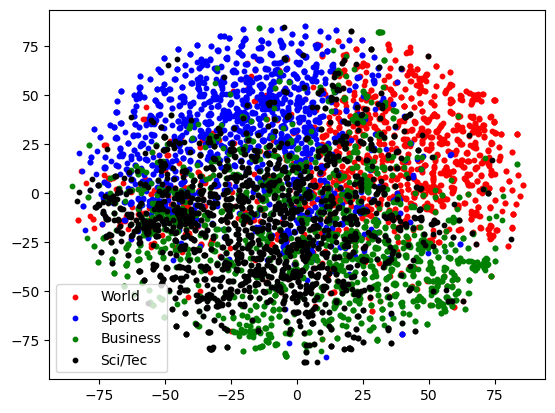

In [37]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

embeddings = []
y_gt = []

with torch.no_grad():
    for x, y in val_dataloader:
        embeddings.append(classifier.embedding_layer(x).mean(1).detach().cpu().numpy())
        y_gt.append(y)
embeddings = np.concatenate(embeddings, 0)
y_gt = np.concatenate(y_gt, 0)

X_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(embeddings)
cdict = {0: 'red', 1: 'blue', 2: 'green', 3: 'black'}


fig, ax = plt.subplots()
for g in np.unique(y_gt):
    ix = np.where(y_gt == g)
    ax.scatter(X_embedded[ix[0]][:, 0], X_embedded[ix[0]][:, 1], c = cdict[g], label = target_classes[g], s = 10)
ax.legend()
plt.show()